In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.listdir('/content/sample_data'))

['README.md', 'anscombe.json', 'engine_fault_detection_dataset.csv', 'california_housing_test.csv', 'mnist_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv']


In [3]:
# Load the dataset
df = pd.read_csv('/content/sample_data/engine_fault_detection_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean,Engine_Condition
0,3.807947,1.899522,1465.396656,106.577348,319.564816,110.834195,3733.620495,91.279833,104.544934,0.889443,0.294582,0
1,9.512072,1.697915,385.333751,85.115094,237.927110,89.671023,4417.399188,114.855139,84.358093,0.916455,0.268216,0
2,7.346740,0.921962,706.346595,145.739823,250.543690,71.727937,2369.581389,97.479227,108.393914,0.440535,0.182008,0
3,6.026719,3.055970,1333.295661,56.277414,272.268451,104.198507,1516.975785,98.518121,105.296723,0.308468,0.251674,2
4,1.644585,2.409290,974.536902,100.542770,281.461334,85.120688,1662.348214,96.787358,107.565599,0.272495,0.188897,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vibration_Amplitude    10000 non-null  float64
 1   RMS_Vibration          10000 non-null  float64
 2   Vibration_Frequency    10000 non-null  float64
 3   Surface_Temperature    10000 non-null  float64
 4   Exhaust_Temperature    10000 non-null  float64
 5   Acoustic_dB            10000 non-null  float64
 6   Acoustic_Frequency     10000 non-null  float64
 7   Intake_Pressure        10000 non-null  float64
 8   Exhaust_Pressure       10000 non-null  float64
 9   Frequency_Band_Energy  10000 non-null  float64
 10  Amplitude_Mean         10000 non-null  float64
 11  Engine_Condition       10000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 937.6 KB


### Distribution of Engine Conditions

Let's visualize the counts of each `Engine_Condition` to understand their distribution.

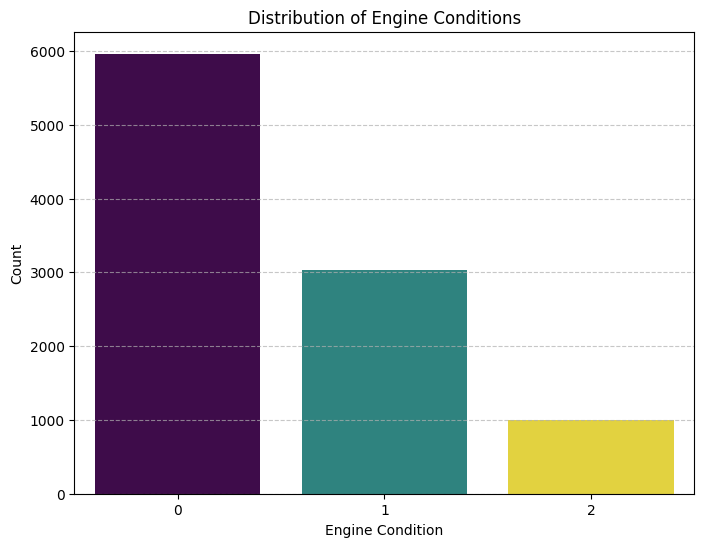

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Engine_Condition', data=df, palette='viridis', hue='Engine_Condition', legend=False)
plt.title('Distribution of Engine Conditions')
plt.xlabel('Engine Condition')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
features = df.columns.drop('Engine_Condition')

### Overall Distribution of Each Feature

Let's visualize the overall distribution of each feature using box plots, without grouping by `Engine_Condition`. This helps in understanding the spread, central tendency, and potential outliers for each feature.

/tmp/ipykernel_5138/4197380173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/4197380173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/4197380173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/4197380173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

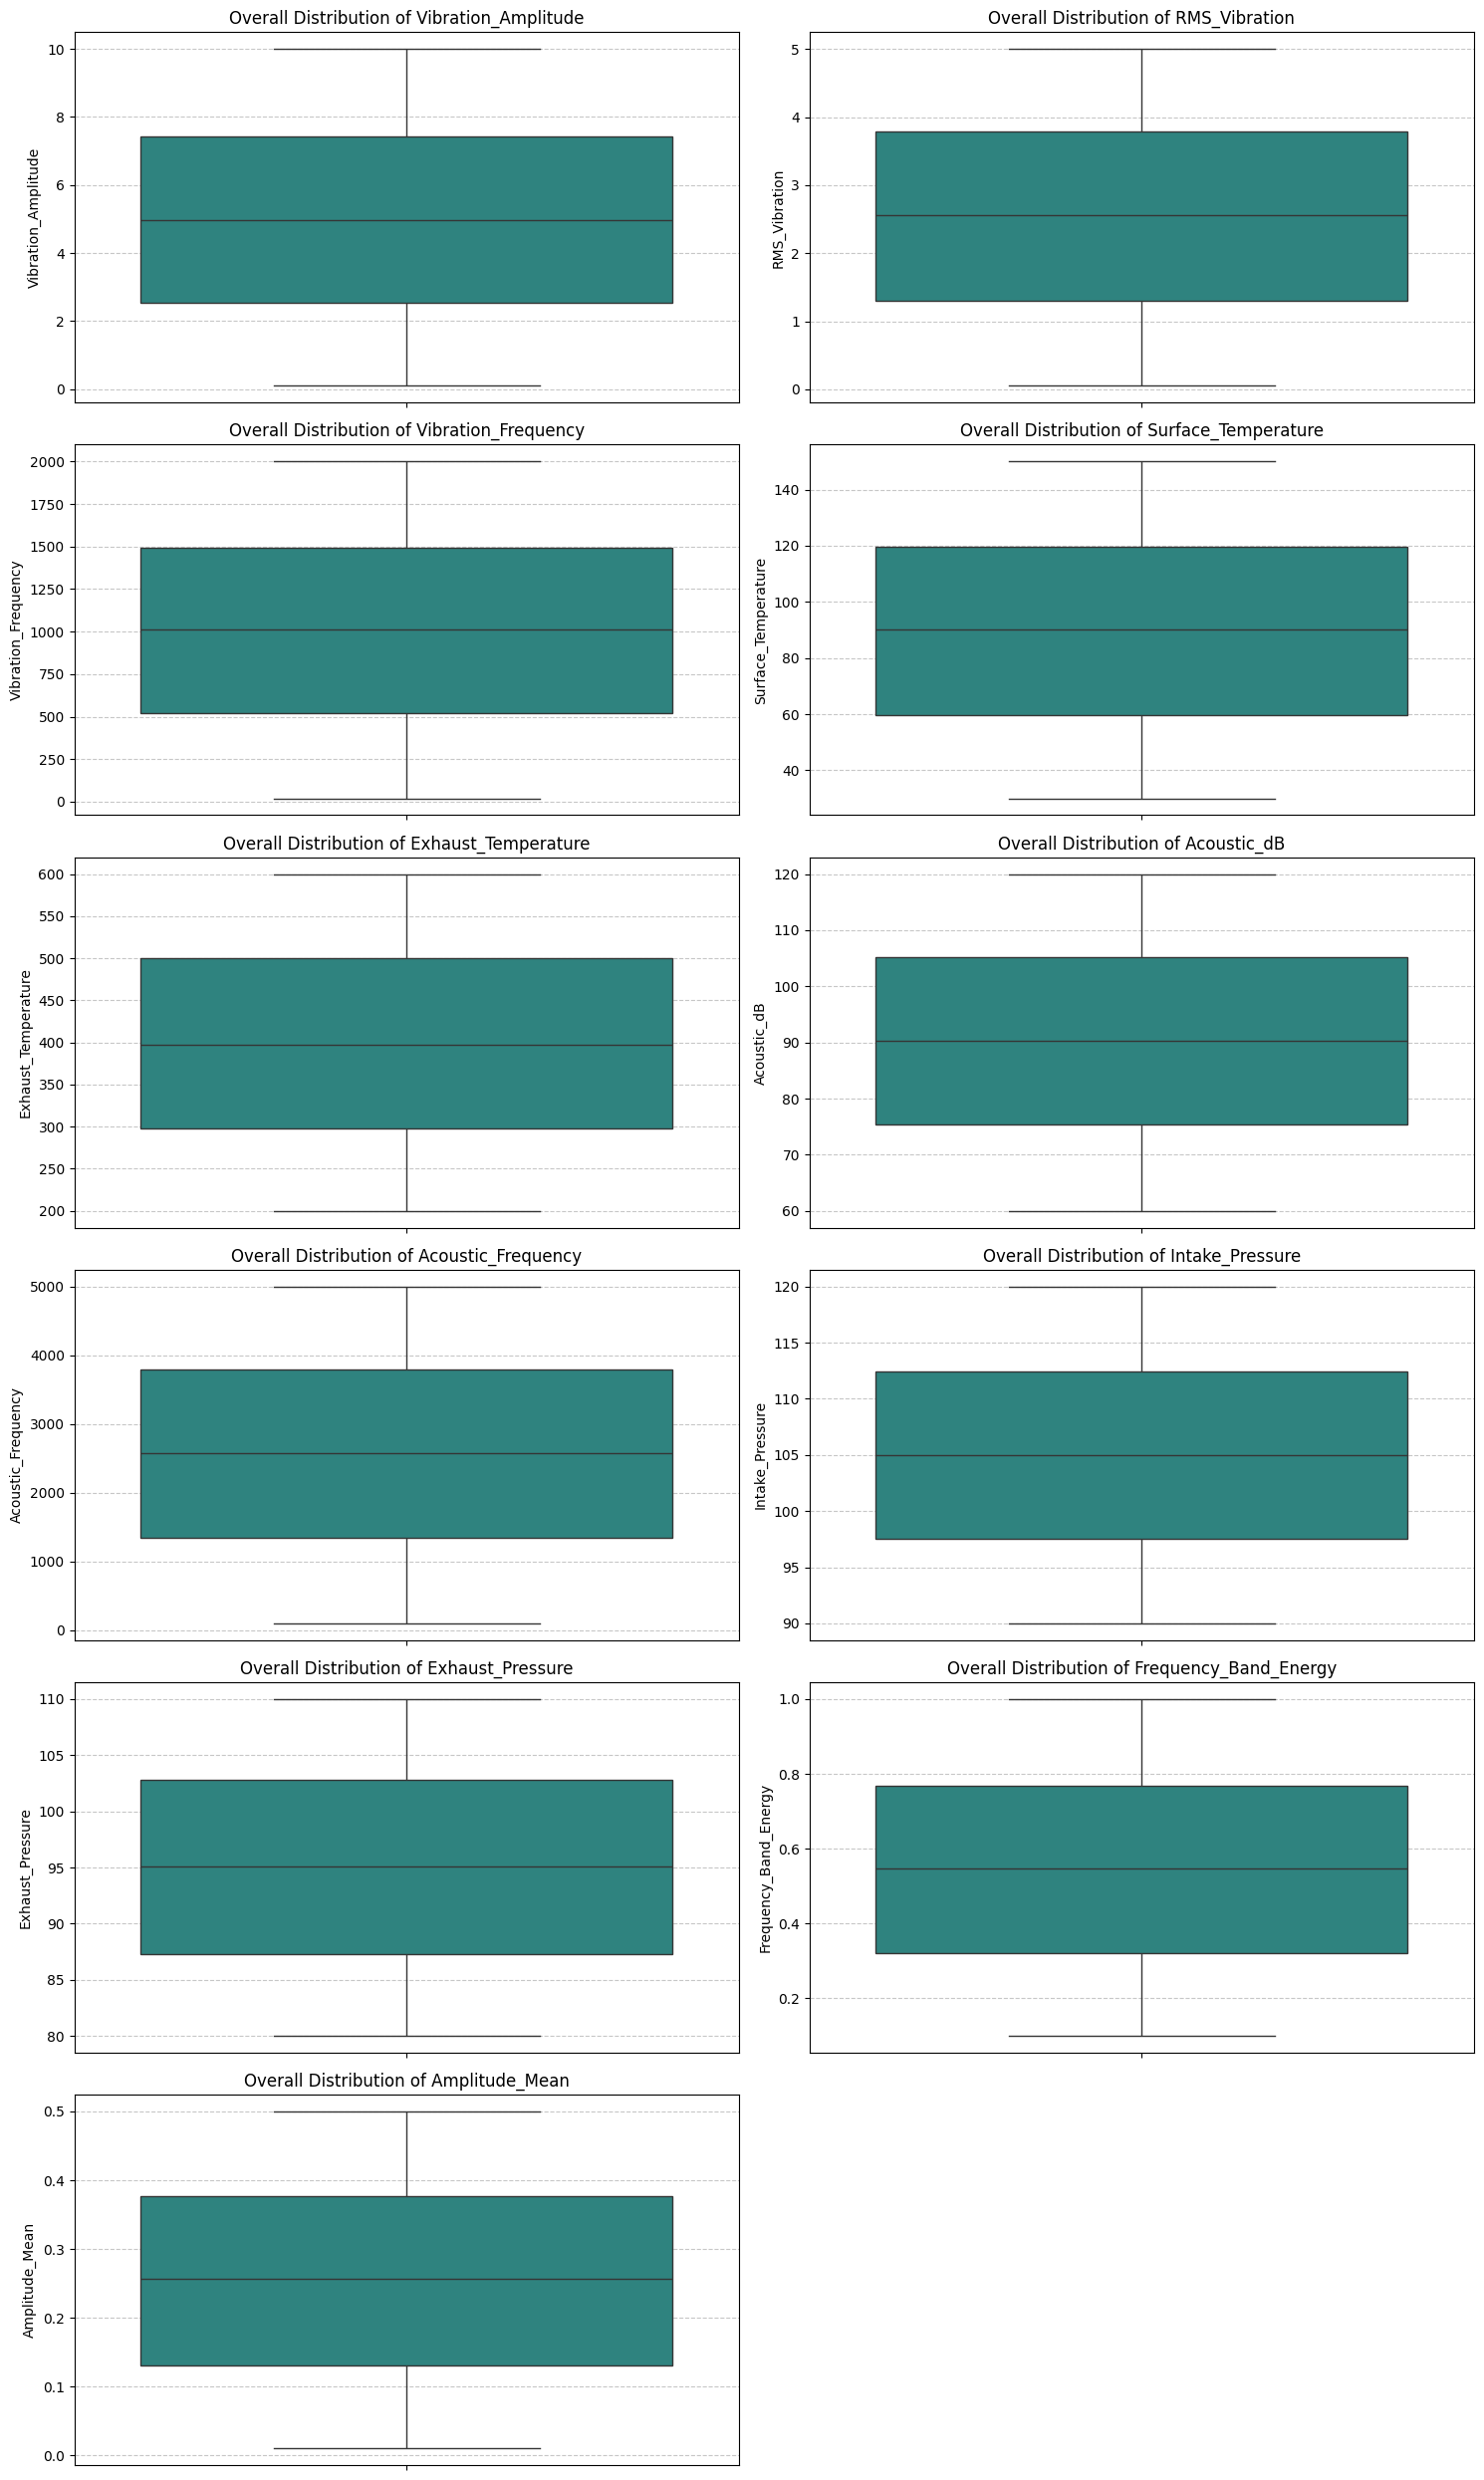

In [9]:
plt.figure(figsize=(15, 25))
for i, feature in enumerate(features):
    plt.subplot(6, 2, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=feature, data=df, palette='viridis') # Only y-axis as feature
    plt.title(f'Overall Distribution of {feature}')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Outlier Handling using IQR Capping

Outliers can disproportionately influence machine learning models. To mitigate their impact without losing data, we will apply **IQR-based capping**.

This method involves:
1.  Calculating the first quartile (Q1) and third quartile (Q3).
2.  Determining the Interquartile Range (IQR = Q3 - Q1).
3.  Defining upper and lower bounds: `Upper Bound = Q3 + 1.5 * IQR`, `Lower Bound = Q1 - 1.5 * IQR`.
4.  Replacing any feature value greater than the upper bound with the upper bound, and any value less than the lower bound with the lower bound.

In [11]:
# Create a copy of the DataFrame to apply outlier capping
df_capped = df.copy()

for feature in features:
    Q1 = df_capped[feature].quantile(0.25)
    Q3 = df_capped[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    df_capped[feature] = np.where(
        df_capped[feature] > upper_bound, upper_bound,
        np.where(df_capped[feature] < lower_bound, lower_bound, df_capped[feature])
    )

print("Outliers capped successfully. Displaying descriptive statistics of the capped DataFrame:")
display(df_capped.describe())

Outliers capped successfully. Displaying descriptive statistics of the capped DataFrame:


,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean,Engine_Condition
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992180,2.547423,1010.099781,89.845606,398.745522,90.188675,2558.761766,104.976734,95.031300,0.545828,0.255133,0.503700
std,2.847538,1.432008,567.812039,34.679351,115.713672,17.300477,1409.523813,8.579042,8.749599,0.258961,0.141254,0.670844
min,0.100115,0.050781,20.095285,30.000664,200.006695,60.000506,101.323600,90.003900,80.003865,0.100026,0.010048,0.000000
25%,2.538656,1.307032,522.420864,59.622870,297.708889,75.417389,1344.035229,97.559952,87.314803,0.320392,0.130852,0.000000
50%,4.976033,2.554189,1014.094827,90.003629,397.486877,90.365423,2570.626283,104.976943,95.127134,0.546940,0.256507,0.000000
75%,7.426063,3.794572,1494.454231,119.653950,500.190814,105.206758,3787.099025,112.434660,102.769823,0.768050,0.377475,1.000000
max,9.997205,4.999628,1999.803934,149.974725,599.988859,119.996382,4998.480399,119.996253,109.999761,0.999978,0.499890,2.000000


### Visualize Distributions After Outlier Capping

Let's re-visualize the overall distribution of each feature using box plots after applying the outlier capping. This will show the effect of the capping on the extreme values.

/tmp/ipykernel_5138/785706476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df_capped, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/785706476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df_capped, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/785706476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=feature, data=df_capped, palette='viridis') # Only y-axis as feature
/tmp/ipykernel_5138/785706476.py:4: FutureWarning: 

Passing `palette` without assigning

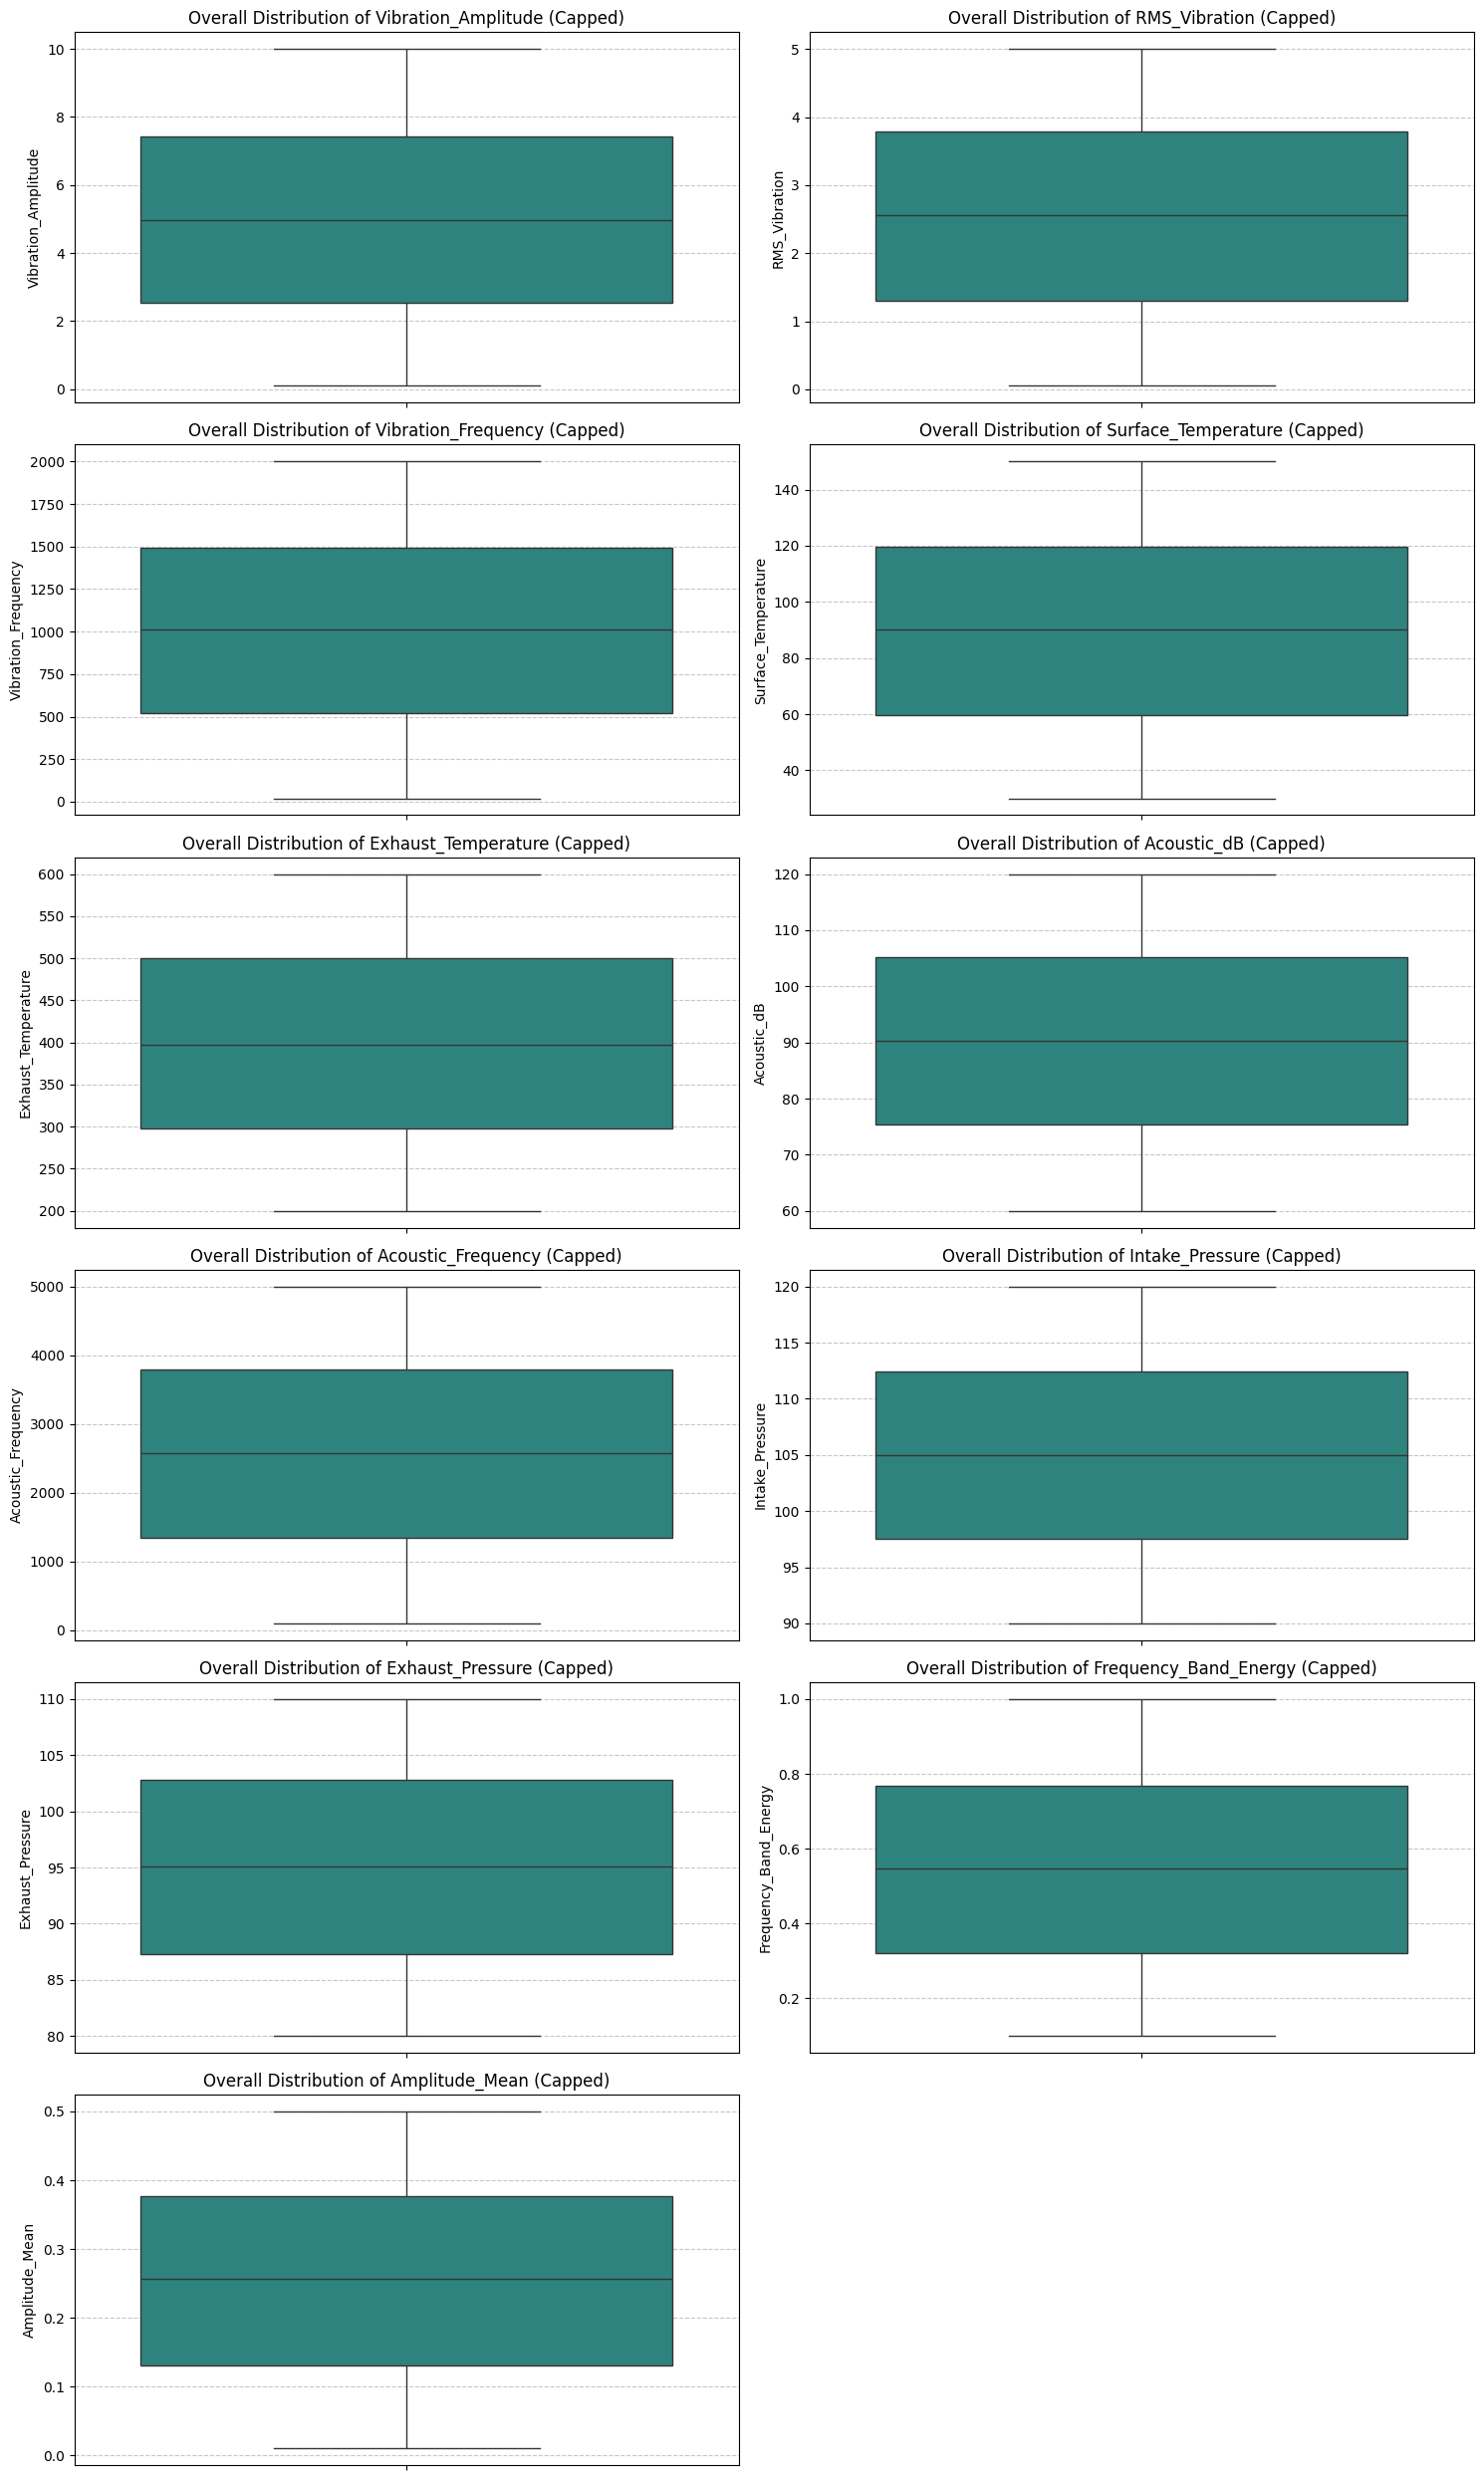

In [12]:
plt.figure(figsize=(15, 25))
for i, feature in enumerate(features):
    plt.subplot(6, 2, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=feature, data=df_capped, palette='viridis') # Only y-axis as feature
    plt.title(f'Overall Distribution of {feature} (Capped)')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()